# 2D Fields Correlations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import usefulfunc as uf
import xarray as xr
import dask
import cartopy.crs as ccrs
import os
from matplotlib.colors import TwoSlopeNorm
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import gc

In [2]:
WORK = os.environ["WORK"]   

In [3]:
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 24,
    'axes.titlesize': 26,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
})

In [9]:
year1 = str(2005)

Let's do a test first

In [10]:
# information for ERA5 dataset.  See https://rda.ucar.edu/datasets/d633000/ 
pl = 'e5.oper.an.pl/'   # pressure level data
sl = 'e5.oper.an.sfc/'  # surface data
fmf = 'e5.oper.fc.sfc.meanflux/' # forecast mean fluxes
era5 = '/glade/campaign/collections/rda/data/d633000/'  # path to the era5 dataset
date = year1 + '*' # the * is to access everything in the inputted year

In [11]:
gzfile = era5 + pl + date + '/e5.oper.an.pl.128_129_z.ll025sc.' + date + '.nc'

In [12]:
precipfluxfile = era5 + fmf + date + '/e5.oper.fc.sfc.meanflux.235_055_mtpr.ll025sc.' + date + '.nc'

In [13]:
precipflux = xr.open_mfdataset(precipfluxfile)

In [10]:
gz = xr.open_mfdataset(gzfile) 

/glade/derecho/scratch/leonardgu/tmp/ipykernel_48584/4093619060.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "level" starting at index 34. This could degrade performance. Instead, consider rechunking after loading.
  gz = xr.open_mfdataset(gzfile, chunks='auto')
/glade/derecho/scratch/leonardgu/tmp/ipykernel_48584/4093619060.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 702. This could degrade performance. Instead, consider rechunking after loading.
  gz = xr.open_mfdataset(gzfile, chunks='auto')
/glade/derecho/scratch/leonardgu/tmp/ipykernel_48584/4093619060.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 1403. This could degrade performance. Instead, consider rechunking after loading.
  gz = xr.open_mfdataset(gzfile, chunks='auto')
/glade/derecho/scratch/leonardgu/tmp/ipykernel_48584/4093619060.py:1: UserWarning: The 

In [14]:
precipflux.MTPR

<xarray.DataArray 'MTPR' (forecast_initial_time: 730, forecast_hour: 12,
                          latitude: 721, longitude: 1440)> Size: 36GB
dask.array<concatenate, shape=(730, 12, 721, 1440), dtype=float32, chunksize=(1, 12, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * forecast_hour          (forecast_hour) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * forecast_initial_time  (forecast_initial_time) datetime64[ns] 6kB 2005-01...
  * latitude               (latitude) float64 6kB 90.0 89.75 ... -89.75 -90.0
  * longitude              (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
Attributes: (12/14)
    long_name:                     Mean total precipitation rate
    short_name:                    mtpr
    units:                         kg m**-2 s**-1
    original_format:               WMO GRIB 1 with ECMWF local table
    ecmwf_local_table:             235
    ecmwf_parameter:               55
    ...                            ...
    grid_specification:            0.25 degree x 0.25 degree from 90N to 90S ...
    rda_dataset:                   ds633.0
    rda_dataset_url:               https:/rda.ucar.edu/datasets/ds633.0/
    rda_dataset_doi:               DOI: 10.5065/BH6N-5N20
    rda_dataset_group:             ERA5 atmospheric surface forecast (mean ra...
    number_of_significant_digits:  7

In [33]:
precipflux.forecast_initial_time.values

array(['2005-01-01T06:00:00.000000000', '2005-01-01T18:00:00.000000000',
       '2005-01-02T06:00:00.000000000', '2005-01-02T18:00:00.000000000',
       '2005-01-03T06:00:00.000000000', '2005-01-03T18:00:00.000000000',
       '2005-01-04T06:00:00.000000000', '2005-01-04T18:00:00.000000000',
       '2005-01-05T06:00:00.000000000', '2005-01-05T18:00:00.000000000',
       '2005-01-06T06:00:00.000000000', '2005-01-06T18:00:00.000000000',
       '2005-01-07T06:00:00.000000000', '2005-01-07T18:00:00.000000000',
       '2005-01-08T06:00:00.000000000', '2005-01-08T18:00:00.000000000',
       '2005-01-09T06:00:00.000000000', '2005-01-09T18:00:00.000000000',
       '2005-01-10T06:00:00.000000000', '2005-01-10T18:00:00.000000000',
       '2005-01-11T06:00:00.000000000', '2005-01-11T18:00:00.000000000',
       '2005-01-12T06:00:00.000000000', '2005-01-12T18:00:00.000000000',
       '2005-01-13T06:00:00.000000000', '2005-01-13T18:00:00.000000000',
       '2005-01-14T06:00:00.000000000', '2005-01-14

In [15]:
init_times, fcast_hours = np.meshgrid(
    precipflux.forecast_initial_time.values,
    precipflux.forecast_hour.values,
    indexing='ij'
)
actual_times = init_times.ravel() + (fcast_hours.ravel().astype('timedelta64[h]'))

mtpr_flat = precipflux.stack(time_flat=('forecast_initial_time', 'forecast_hour'))
mtpr_flat = mtpr_flat.assign_coords(time=('time_flat', actual_times))
mtpr_flat = mtpr_flat.swap_dims({'time_flat': 'time'})
mtpr_flat = mtpr_flat.drop_vars(['forecast_initial_time', 'forecast_hour', 'time_flat'])
mtpr_flat = mtpr_flat.sortby('time')

In [16]:
mtpr_flat

<xarray.Dataset> Size: 36GB
Dimensions:    (latitude: 721, longitude: 1440, time: 8760)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 70kB 2005-01-01T07:00:00 ... 2006-01-01T...
Data variables:
    MTPR       (latitude, longitude, time) float32 36GB dask.array<chunksize=(721, 1440, 12), meta=np.ndarray>
    utc_date   (time) int32 35kB dask.array<chunksize=(360,), meta=np.ndarray>
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.6.1
    CONVERSION_PLATFORM:  Linux casper21 3.10.0-693.21.1.el7.x86_64 #1 SMP We...
    CONVERSION_DATE:      Wed Aug  7 11:20:39 MDT 2019
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Wed Aug  7 11:20:47 2019: ncks -4 --ppc default=7 e...
    NCO:                  netCDF Operators version 4.7.4 (http://nco.sf.net)

In [17]:
mtpr_daily = mtpr_flat.resample(time='1D').mean('time').compute()
mtpr_daily_m = mtpr_daily * 86400 / 1000

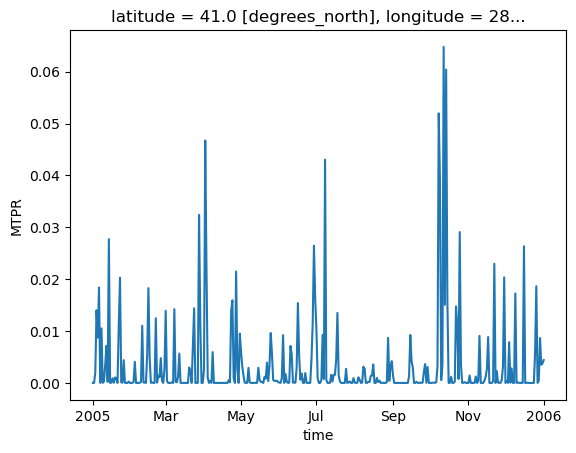

In [23]:
mtpr_daily_m.MTPR.sel(latitude=41, longitude=286).plot()

In [25]:
precip2005i = uf.interpleapyear_2d(mtpr_daily_m.MTPR, 2005)

2005 is a leap year!
Year 2005: NEW interpolated shape = (721, 1440, 365)
Year 2005: TRANSPOSED interpolated shape = (365, 721, 1440)


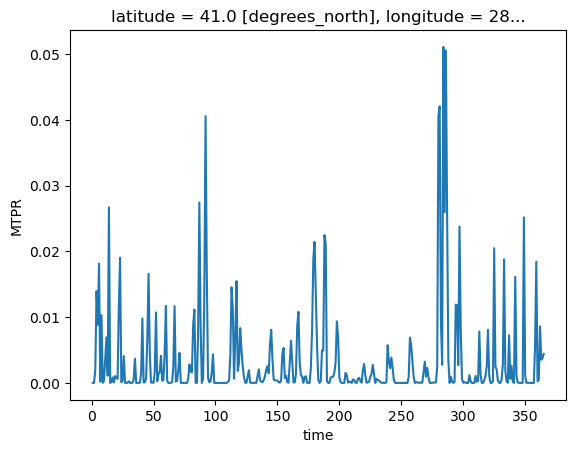

In [27]:
precip2005i.sel(latitude=41, longitude=286).plot()

In [11]:
z=gz.Z / 9.8

In [12]:
z850 = z.sel(level=850)

In [13]:
z850daily = z850.resample(time='1D').mean('time')

In [14]:
z850daily

<xarray.DataArray 'Z' (time: 365, latitude: 721, longitude: 1440)> Size: 2GB
dask.array<transpose, shape=(365, 721, 1440), dtype=float32, chunksize=(1, 702, 1403), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    level      float64 8B 850.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 3kB 2005-01-01 2005-01-02 ... 2005-12-31

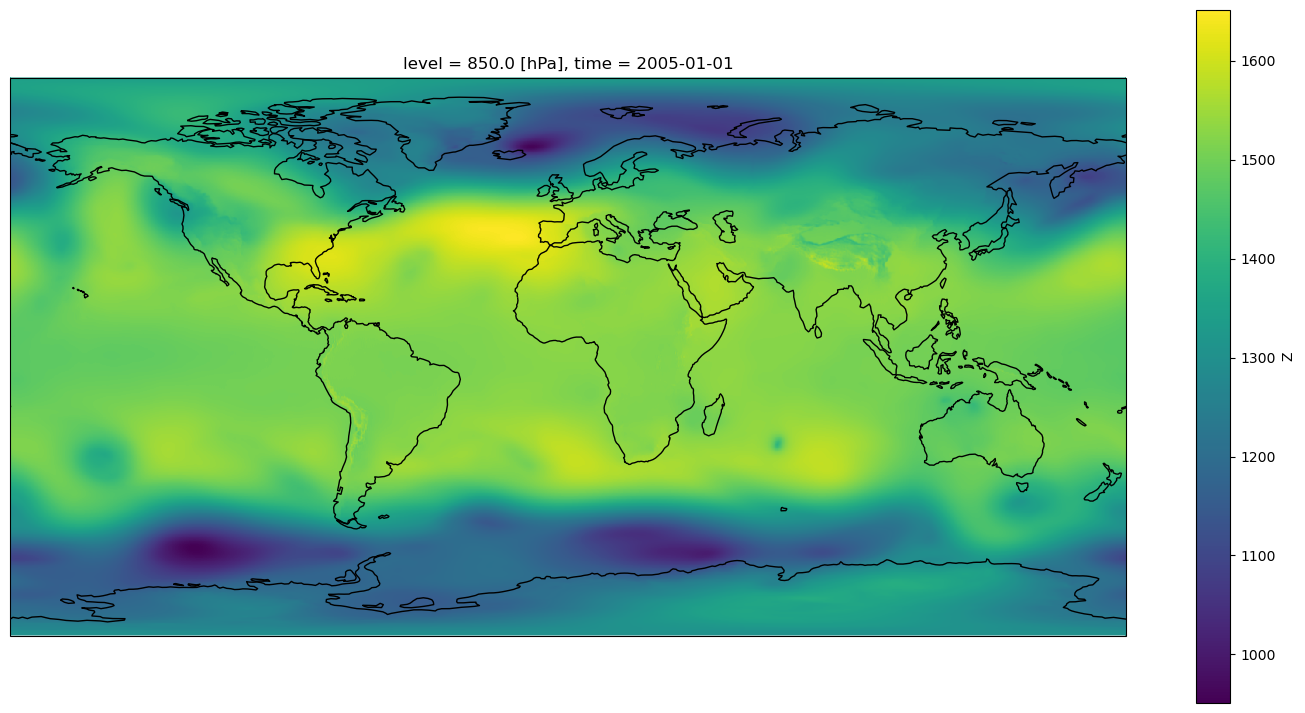

In [21]:
fig, ax = plt.subplots(1,1, figsize=(18,9), subplot_kw=dict(projection=ccrs.PlateCarree()))

z850daily.sel(time = '2005-01-01').plot(
    transform=ccrs.PlateCarree(),

)

ax.coastlines()

In [3]:
filepath1 = f'{WORK}/tam/z8502d'

In [4]:
filepath2 = f'{WORK}/tam/MSLP2d'

In [3]:
filepath3 = f'{WORK}/tam/mtpr2d'

In [7]:
filepath4 = f'{WORK}/tam/z2002d'

In [7]:
test = xr.open_mfdataset(f'{WORK}/tam/mtpr2d/MTPRdaily2005.nc')

In [4]:
precipanncycfile = uf.annual_cycle_2d(filepath3, 'MTPRdaily', 'MTPR',  1979, 2023, f'{WORK}/tam/annual_cycles/precip2danncyc.nc')

Year 1979: original shape = (721, 1440, 366)
1979 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 1979: NEW interpolated shape = (721, 1440, 365)
Year 1979: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 1980: original shape = (721, 1440, 367)
1980 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 1980: NEW interpolated shape = (721, 1440, 365)
Year 1980: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 1981: original shape = (721, 1440, 366)
1981 is a leap year or does not have 365 time coordinates!


...

Year 2021: NEW interpolated shape = (721, 1440, 365)
Year 2021: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 2022: original shape = (721, 1440, 366)
2022 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 2022: NEW interpolated shape = (721, 1440, 365)
Year 2022: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 2023: original shape = (721, 1440, 366)
2023 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 2023: NEW interpolated shape = (721, 1440, 365)
Year 2023: TRANSPOSED interpolated shape = (365, 721, 1440)
Computing and writing annual cycle to /glade/work/leonardgu/tam/annual_cycles/precip2danncyc.nc
Done!


In [8]:
z200anncycfile = uf.annual_cycle_2d(filepath4, 'z200daily', 'Z',  1979, 2023, f'{WORK}/tam/annual_cycles/z2002danncyc.nc')

Year 1979: original shape = (365, 721, 1440)
Year 1980: original shape = (366, 721, 1440)
1980 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 1980: NEW interpolated shape = (721, 1440, 365)
Year 1980: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 1981: original shape = (365, 721, 1440)
Year 1982: original shape = (365, 721, 1440)
Year 1983: original shape = (365, 721, 1440)
Year 1984: original shape = (366, 721, 1440)
1984 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 1984: NEW interpolated shape = (721, 1440, 365)
Year 1984: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 1985: original shape = (365, 721, 1440)
Year 1986: original shape = (365, 721, 1440)
Year 1987: original shape = (365, 721, 1440)
Year 1988: original shape = (366, 721, 1440)
1988 is a leap year or does not have 365 time coordinates!


...

Year 2012: NEW interpolated shape = (721, 1440, 365)
Year 2012: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 2013: original shape = (365, 721, 1440)
Year 2014: original shape = (365, 721, 1440)
Year 2015: original shape = (365, 721, 1440)
Year 2016: original shape = (366, 721, 1440)
2016 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 2016: NEW interpolated shape = (721, 1440, 365)
Year 2016: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 2017: original shape = (365, 721, 1440)
Year 2018: original shape = (365, 721, 1440)
Year 2019: original shape = (365, 721, 1440)
Year 2020: original shape = (366, 721, 1440)
2020 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 2020: NEW interpolated shape = (721, 1440, 365)
Year 2020: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 2021: original shape = (365, 721, 1440)
Year 2022: original shape = (365, 721, 1440)
Year 2023: original shape = (365, 721, 1440)
Computing and writing annual cycle to /glade/work/leonardgu/tam/annual_cycles/z2002danncyc.nc
Done!


In [4]:
z850anncycfile = uf.annual_cycle_2d(filepath1, 'z850daily', 'Z',  1979, 2023, f'{WORK}/tam/annual_cycles/z8502danncyc.nc')

Year 1979: original shape = (365, 721, 1440)
Year 1980: original shape = (366, 721, 1440)
1980 is a leap year!


/glade/u/home/leonardgu/tam/usefulfunc.py:59: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 1980: NEW interpolated shape = (721, 1440, 365)
Year 1980: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 1981: original shape = (365, 721, 1440)
Year 1982: original shape = (365, 721, 1440)
Year 1983: original shape = (365, 721, 1440)
Year 1984: original shape = (366, 721, 1440)
1984 is a leap year!


/glade/u/home/leonardgu/tam/usefulfunc.py:59: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 1984: NEW interpolated shape = (721, 1440, 365)
Year 1984: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 1985: original shape = (365, 721, 1440)
Year 1986: original shape = (365, 721, 1440)
Year 1987: original shape = (365, 721, 1440)
Year 1988: original shape = (366, 721, 1440)
1988 is a leap year!


...

Year 2012: NEW interpolated shape = (721, 1440, 365)
Year 2012: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 2013: original shape = (365, 721, 1440)
Year 2014: original shape = (365, 721, 1440)
Year 2015: original shape = (365, 721, 1440)
Year 2016: original shape = (366, 721, 1440)
2016 is a leap year!


/glade/u/home/leonardgu/tam/usefulfunc.py:59: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 2016: NEW interpolated shape = (721, 1440, 365)
Year 2016: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 2017: original shape = (365, 721, 1440)
Year 2018: original shape = (365, 721, 1440)
Year 2019: original shape = (365, 721, 1440)
Year 2020: original shape = (366, 721, 1440)
2020 is a leap year!


/glade/u/home/leonardgu/tam/usefulfunc.py:59: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 2020: NEW interpolated shape = (721, 1440, 365)
Year 2020: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 2021: original shape = (365, 721, 1440)
Year 2022: original shape = (365, 721, 1440)
Year 2023: original shape = (365, 721, 1440)
Computing and writing annual cycle to /glade/work/leonardgu/tam/annual_cycles/z8502danncyc.nc
Done!


In [5]:
MSLPanncycfile = uf.annual_cycle_2d(filepath2, 'MSLdaily', 'MSL', 1979, 2023, f'{WORK}/tam/annual_cycles/MSL2danncyc.nc')

Year 1979: original shape = (365, 721, 1440)
Year 1980: original shape = (366, 721, 1440)
1980 is a leap year!


/glade/u/home/leonardgu/tam/usefulfunc.py:65: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 1980: NEW interpolated shape = (721, 1440, 365)
Year 1980: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 1981: original shape = (365, 721, 1440)
Year 1982: original shape = (365, 721, 1440)
Year 1983: original shape = (365, 721, 1440)
Year 1984: original shape = (366, 721, 1440)
1984 is a leap year!


/glade/u/home/leonardgu/tam/usefulfunc.py:65: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 1984: NEW interpolated shape = (721, 1440, 365)
Year 1984: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 1985: original shape = (365, 721, 1440)
Year 1986: original shape = (365, 721, 1440)
Year 1987: original shape = (365, 721, 1440)
Year 1988: original shape = (366, 721, 1440)
1988 is a leap year!


...

Year 2012: NEW interpolated shape = (721, 1440, 365)
Year 2012: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 2013: original shape = (365, 721, 1440)
Year 2014: original shape = (365, 721, 1440)
Year 2015: original shape = (365, 721, 1440)
Year 2016: original shape = (366, 721, 1440)
2016 is a leap year!


/glade/u/home/leonardgu/tam/usefulfunc.py:65: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 2016: NEW interpolated shape = (721, 1440, 365)
Year 2016: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 2017: original shape = (365, 721, 1440)
Year 2018: original shape = (365, 721, 1440)
Year 2019: original shape = (365, 721, 1440)
Year 2020: original shape = (366, 721, 1440)
2020 is a leap year!


/glade/u/home/leonardgu/tam/usefulfunc.py:65: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 2020: NEW interpolated shape = (721, 1440, 365)
Year 2020: TRANSPOSED interpolated shape = (365, 721, 1440)
Year 2021: original shape = (365, 721, 1440)
Year 2022: original shape = (365, 721, 1440)
Year 2023: original shape = (365, 721, 1440)
Computing and writing annual cycle to /glade/work/leonardgu/tam/annual_cycles/MSL2danncyc.nc
Done!


In [6]:
MSLPanncyc = xr.open_mfdataset(f'{WORK}/tam/annual_cycles/MSL2danncyc.nc')

In [5]:
z200anncyc = xr.open_mfdataset(f'{WORK}/tam/annual_cycles/z2002danncyc.nc')

In [7]:
MSLPanncyc.MSL

<xarray.DataArray 'MSL' (time: 365, latitude: 721, longitude: 1440)> Size: 3GB
dask.array<open_dataset-MSL, shape=(365, 721, 1440), dtype=float64, chunksize=(365, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8

In [3]:
z850anncyc = xr.open_mfdataset(f'{WORK}/tam/annual_cycles/z8502danncyc.nc')

In [4]:
z850anncyc.Z

<xarray.DataArray 'Z' (time: 365, latitude: 721, longitude: 1440)> Size: 3GB
dask.array<open_dataset-Z, shape=(365, 721, 1440), dtype=float64, chunksize=(365, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8

In [3]:
precipanncyc = xr.open_mfdataset(f'{WORK}/tam/annual_cycles/precip2danncyc.nc')

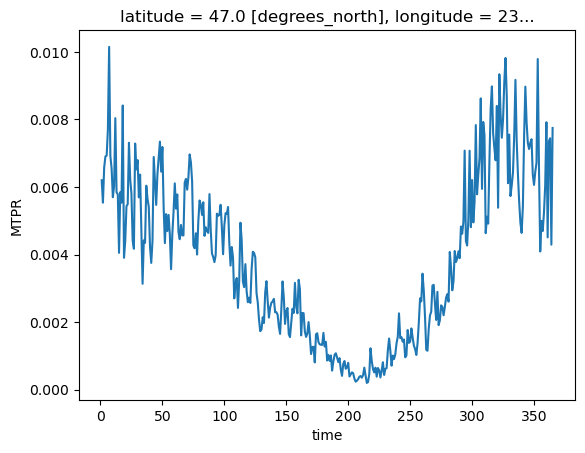

In [10]:
precipanncyc.MTPR.sel(latitude=47, longitude=237).plot()

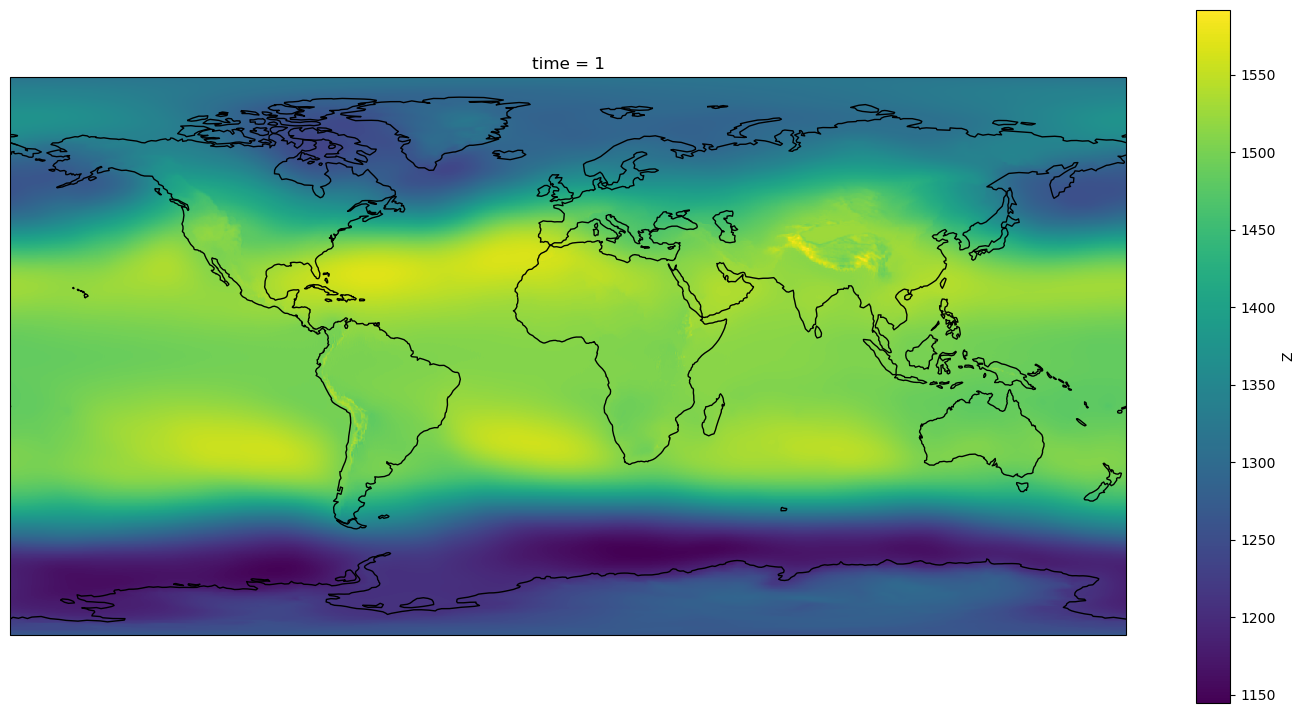

In [40]:
fig, ax = plt.subplots(1,1, figsize=(18,9), subplot_kw=dict(projection=ccrs.PlateCarree()))

z850anncyc.Z.sel(time = 1).plot(
    transform=ccrs.PlateCarree(),

)

ax.coastlines()

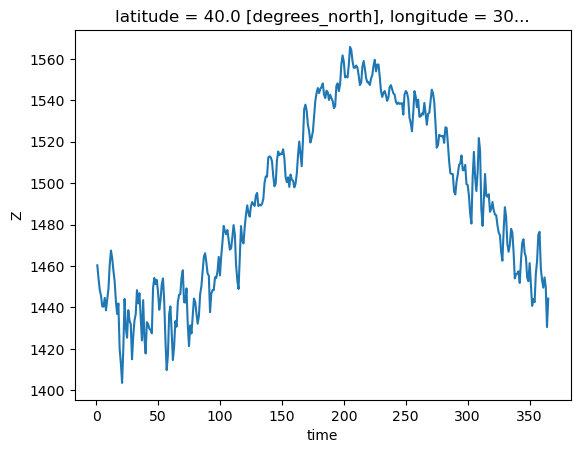

In [41]:
z850anncyc.Z.sel(latitude = 40, longitude = 300).plot()

In [9]:
z8502dpath = f'{WORK}/tam/z8502d'

In [9]:
MSLP2dpath =  f'{WORK}/tam/MSLP2d'

## MTPR2dpath =  f'{WORK}/tam/mtpr2d'

In [4]:
z2002dpath = f'{WORK}/tam/z2002d'

In [16]:
for year in range(1979, 2024):
    z2002danoms = uf.calcanomaly_2d(z200anncyc ,f'{z2002dpath}/z200daily{year}.nc', 'Z')
    z2002danoms.to_netcdf(f'{WORK}/tam/anoms/z2002d_anomalies/z200dailyanom{year}.nc')


1980 is a leap year or does not have 365 time coordinates!
Year 1980: NEW interpolated shape = (721, 1440, 365)
Year 1980: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


1984 is a leap year or does not have 365 time coordinates!
Year 1984: NEW interpolated shape = (721, 1440, 365)
Year 1984: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


1988 is a leap year or does not have 365 time coordinates!
Year 1988: NEW interpolated shape = (721, 1440, 365)
Year 1988: TRANSPOSED interpolated shape = (365, 721, 1440)


...

/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


2016 is a leap year or does not have 365 time coordinates!
Year 2016: NEW interpolated shape = (721, 1440, 365)
Year 2016: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


2020 is a leap year or does not have 365 time coordinates!
Year 2020: NEW interpolated shape = (721, 1440, 365)
Year 2020: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


In [10]:
for year in range(1979, 2024):
    MSL2danoms = uf.calcanomaly_2d(MSLPanncyc ,f'{MSLP2dpath}/MSLdaily{year}.nc', 'MSL')
    MSL2danoms.to_netcdf(f'{WORK}/tam/anoms/MSLP2d_anomalies/MSLdailyanom{year}.nc')


1980 is a leap year!
Year 1980: NEW interpolated shape = (721, 1440, 365)
Year 1980: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:65: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


1984 is a leap year!
Year 1984: NEW interpolated shape = (721, 1440, 365)
Year 1984: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:65: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


1988 is a leap year!
Year 1988: NEW interpolated shape = (721, 1440, 365)
Year 1988: TRANSPOSED interpolated shape = (365, 721, 1440)


...

/glade/u/home/leonardgu/tam/usefulfunc.py:65: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


2016 is a leap year!
Year 2016: NEW interpolated shape = (721, 1440, 365)
Year 2016: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:65: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


2020 is a leap year!
Year 2020: NEW interpolated shape = (721, 1440, 365)
Year 2020: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:65: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


In [10]:
for year in range(1979, 2024):
    z850anoms = uf.calcanomaly_2d(z850anncyc ,f'{z8502dpath}/z850daily{year}.nc', 'Z')
    z850anoms.to_netcdf(f'{WORK}/tam/anoms/z850_anomalies/z850dailyanom{year}.nc')


1980 is a leap year!
Year 1980: NEW interpolated shape = (721, 1440, 365)
Year 1980: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:59: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


1984 is a leap year!
Year 1984: NEW interpolated shape = (721, 1440, 365)
Year 1984: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:59: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


1988 is a leap year!
Year 1988: NEW interpolated shape = (721, 1440, 365)
Year 1988: TRANSPOSED interpolated shape = (365, 721, 1440)


...

/glade/u/home/leonardgu/tam/usefulfunc.py:59: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


2016 is a leap year!
Year 2016: NEW interpolated shape = (721, 1440, 365)
Year 2016: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:59: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


2020 is a leap year!
Year 2020: NEW interpolated shape = (721, 1440, 365)
Year 2020: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:59: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


In [6]:
for year in range(1979, 2024):
    precipanoms = uf.calcanomaly_2d(precipanncyc ,f'{MTPR2dpath}/MTPRdaily{year}.nc', 'MTPR')
    precipanoms.to_netcdf(f'{WORK}/tam/anoms/precip_anomalies/precipdailyanom{year}.nc')


1979 is a leap year or does not have 365 time coordinates!
Year 1979: NEW interpolated shape = (721, 1440, 365)
Year 1979: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


1980 is a leap year or does not have 365 time coordinates!
Year 1980: NEW interpolated shape = (721, 1440, 365)
Year 1980: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


1981 is a leap year or does not have 365 time coordinates!
Year 1981: NEW interpolated shape = (721, 1440, 365)
Year 1981: TRANSPOSED interpolated shape = (365, 721, 1440)


...

/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


2022 is a leap year or does not have 365 time coordinates!
Year 2022: NEW interpolated shape = (721, 1440, 365)
Year 2022: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


2023 is a leap year or does not have 365 time coordinates!
Year 2023: NEW interpolated shape = (721, 1440, 365)
Year 2023: TRANSPOSED interpolated shape = (365, 721, 1440)


/glade/u/home/leonardgu/tam/usefulfunc.py:66: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


In [12]:
z8502danom1979_2023 = uf.stackanoms_2d('z850', 'Z')

In [6]:
z2002danom1979_2023 = uf.stackanoms_2d('z200', 'Z')

In [7]:
z2002danom1979_2023.to_netcdf(f'{WORK}/tam/full_anoms/z2002danom1979_2023.nc')

In [13]:
MSL2danom1979_2023 = uf.stackanoms_2d('MSL', 'MSL')

In [3]:
precip2danom1979_2023 = uf.stackanoms_2d('precip', 'MTPR')

In [15]:
z8502danom1979_2023.to_netcdf(f'{WORK}/tam/full_anoms/z8502danom1979_2023.nc')

In [15]:
MSL2danom1979_2023.to_netcdf(f'{WORK}/tam/full_anoms/MSL2danom1979_2023.nc')

In [5]:
precip2danom1979_2023.to_netcdf(f'{WORK}/tam/full_anoms/precip2danom1979_2023.nc')

In [16]:
MSL2danom = xr.open_mfdataset(f'{WORK}/tam/full_anoms/MSL2danom1979_2023.nc')

In [4]:
z8502danom = xr.open_mfdataset(f'{WORK}/tam/full_anoms/z8502danom1979_2023.nc')

In [8]:
z2002danom = xr.open_mfdataset(f'{WORK}/tam/full_anoms/z2002danom1979_2023.nc')

In [6]:
precip2danom = xr.open_mfdataset(f'{WORK}/tam/full_anoms/precip2danom1979_2023.nc')

In [17]:
MSL2danom_st = MSL2danom.MSL.stack(alltime = ('year','time'))

In [5]:
z8502danom_st = z8502danom.Z.stack(alltime = ('year','time'))

In [9]:
z2002danom_st = z2002danom.Z.stack(alltime = ('year','time'))

In [7]:
precip2danom_st = precip2danom.MTPR.stack(alltime = ('year', 'time'))

In [8]:
precip2danom_st

<xarray.DataArray 'MTPR' (latitude: 721, longitude: 1440, alltime: 16425)> Size: 136GB
dask.array<reshape, shape=(721, 1440, 16425), dtype=float64, chunksize=(721, 1440, 16425), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * alltime    (alltime) object 131kB MultiIndex
  * year       (alltime) int64 131kB 1979 1979 1979 1979 ... 2023 2023 2023 2023
  * time       (alltime) int64 131kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365

In [6]:
z8502danom_st

<xarray.DataArray 'Z' (latitude: 721, longitude: 1440, alltime: 16425)> Size: 136GB
dask.array<reshape, shape=(721, 1440, 16425), dtype=float64, chunksize=(721, 1440, 16425), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    level      float64 8B ...
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * alltime    (alltime) object 131kB MultiIndex
  * year       (alltime) int64 131kB 1979 1979 1979 1979 ... 2023 2023 2023 2023
  * time       (alltime) int64 131kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365

In [5]:
highpz850, lowpz850, hfiles, lfiles = uf.butter1yhighp_2d(z8502danom_st, 4, f'{WORK}/tam/temp/')

Processing lats 0-50
Processing lats 50-100
Processing lats 100-150
Processing lats 150-200
Processing lats 200-250
Processing lats 250-300
Processing lats 300-350
Processing lats 350-400
Processing lats 400-450
Processing lats 450-500
Processing lats 500-550
Processing lats 550-600
Processing lats 600-650
Concatenating chunks...


In [11]:
highpz200, _ , _ , _ = uf.butter1yhighp_2d(z2002danom_st, 4, f'{WORK}/tam/temp/')

Processing lats 0-50
Processing lats 50-100
Processing lats 100-150
Processing lats 150-200
Processing lats 200-250
Processing lats 250-300
Processing lats 300-350
Processing lats 350-400
Processing lats 400-450
Processing lats 450-500
Processing lats 500-550
Processing lats 550-600
Processing lats 600-650
Processing lats 650-700
Processing lats 700-721
Concatenating chunks...


In [18]:
highpMSL, lowpMSL, _ , _ = uf.butter1yhighp_2d(MSL2danom_st, 4, f'{WORK}/tam/temp/')

Processing lats 0-50
Processing lats 50-100
Processing lats 100-150
Processing lats 150-200
Processing lats 200-250
Processing lats 250-300
Processing lats 300-350
Processing lats 350-400
Processing lats 400-450
Processing lats 450-500
Processing lats 500-550
Processing lats 550-600
Processing lats 600-650
Processing lats 650-700
Processing lats 700-721
Concatenating chunks...


In [9]:
highpprecip, _ , _ , _ = uf.butter1yhighp_2d(precip2danom_st, 4, f'{WORK}/tam/temp/')

Processing lats 0-50
Processing lats 50-100
Processing lats 100-150
Processing lats 150-200
Processing lats 200-250
Processing lats 250-300
Processing lats 300-350
Processing lats 350-400
Processing lats 400-450
Processing lats 450-500
Processing lats 500-550
Processing lats 550-600
Processing lats 600-650
Processing lats 650-700
Processing lats 700-721
Concatenating chunks...


In [10]:
highpprecip.MTPR

<xarray.DataArray 'MTPR' (latitude: 721, longitude: 1440, alltime: 16425)> Size: 136GB
dask.array<concatenate, shape=(721, 1440, 16425), dtype=float64, chunksize=(50, 1440, 16425), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    year       (alltime) int64 131kB dask.array<chunksize=(16425,), meta=np.ndarray>
    time       (alltime) int64 131kB dask.array<chunksize=(16425,), meta=np.ndarray>
Dimensions without coordinates: alltime

In [19]:
highpMSL.MSL

<xarray.DataArray 'MSL' (latitude: 721, longitude: 1440, alltime: 16425)> Size: 136GB
dask.array<concatenate, shape=(721, 1440, 16425), dtype=float64, chunksize=(50, 1440, 16425), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    year       (alltime) int64 131kB dask.array<chunksize=(16425,), meta=np.ndarray>
    time       (alltime) int64 131kB dask.array<chunksize=(16425,), meta=np.ndarray>
Dimensions without coordinates: alltime

In [8]:
highpz850.Z

<xarray.DataArray 'Z' (latitude: 721, longitude: 1440, alltime: 16425)> Size: 136GB
dask.array<concatenate, shape=(721, 1440, 16425), dtype=float64, chunksize=(50, 1440, 16425), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    level      float64 8B 850.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    year       (alltime) int64 131kB dask.array<chunksize=(16425,), meta=np.ndarray>
    time       (alltime) int64 131kB dask.array<chunksize=(16425,), meta=np.ndarray>
Dimensions without coordinates: alltime

In [6]:

highpz850.to_netcdf(f'{WORK}/tam/filfilt_ts/z850_high.nc')
lowpz850.to_netcdf(f'{WORK}/tam/filfilt_ts/z850_low.nc')

# Cleanup
#for f in h_files + l_files:
   # os.remove(f)


In [20]:
highpMSL.to_netcdf(f'{WORK}/tam/filt_ts/MSL_high.nc')

In [13]:
highpz200.to_netcdf(f'{WORK}/tam/filt_ts/z200_high.nc')

In [11]:
highpprecip.to_netcdf(f'{WORK}/tam/filt_ts/precip_high.nc')

In [3]:
highpz850f = xr.open_mfdataset(f'{WORK}/tam/filt_ts/z850_high.nc')

In [14]:
highpz200f = xr.open_mfdataset(f'{WORK}/tam/filt_ts/z200_high.nc')

In [3]:
highpMSLf = xr.open_mfdataset(f'{WORK}/tam/filt_ts/MSL_high.nc')

edge_trim = 183

highpMSLshaved = highpMSLf.isel(alltime=slice(edge_trim, -edge_trim))

In [25]:
highpprecipf = xr.open_mfdataset(f'{WORK}/tam/filt_ts/precip_high.nc')

edge_trim = 183

highpprecipshaved = highpprecipf.isel(alltime=slice(edge_trim, -edge_trim))

In [19]:
edge_trim = 183

highpz850shaved = highpz850f.isel(alltime=slice(edge_trim, -edge_trim))

NameError: name 'highpz850f' is not defined

In [15]:
edge_trim = 183

highpz200shaved = highpz200f.isel(alltime=slice(edge_trim, -edge_trim))

In [16]:
zmzdanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmzdanoms1979_2023.nc')

In [17]:
eqzmzdanomts = zmzdanoms79_23.Z.sel(latitude = 0).stack(alltime = ('year', 'time'))

In [19]:
highpzmza, lowpzmza = uf.butter1yhighp(eqzmzdanomts, 4)

In [20]:
edge_trim=183
highpZshaved = highpzmza.isel(alltime=slice(edge_trim, -edge_trim))

In [21]:
z850index = highpZshaved.sel(level=850) # Zbar(850) index

In [29]:
z200index = highpZshaved.sel(level=200).reset_index('alltime')

In [22]:
z850index = z850index.reset_index('alltime')

In [23]:
z850index

<xarray.DataArray (alltime: 16059)> Size: 128kB
array([ 5.62038874,  8.9564041 , 11.0406108 , ..., -1.47088302,
        1.84273818,  4.49689445])
Coordinates:
    latitude  float64 8B 0.0
    level     float64 8B 850.0
    year      (alltime) int64 128kB 1979 1979 1979 1979 ... 2023 2023 2023 2023
    time      (alltime) int64 128kB 184 185 186 187 188 ... 178 179 180 181 182
Dimensions without coordinates: alltime

In [24]:
z200corr2d, _ = uf.lag_corr_2d(z850index, highpz200shaved.Z, -5, f'{WORK}/tam/temp/')

Processing lats 0-50
Processing lats 50-100
Processing lats 100-150
Processing lats 150-200
Processing lats 200-250
Processing lats 250-300
Processing lats 300-350
Processing lats 350-400
Processing lats 400-450
Processing lats 450-500
Processing lats 500-550
Processing lats 550-600
Processing lats 600-650
Processing lats 650-700
Processing lats 700-721
Concatenating correlation chunks...


In [37]:
MSLcorr2d, _ = uf.lag_corr_2d(z850index, highpMSLshaved.MSL, 0, f'{WORK}/tam/temp/')

Processing lats 0-50
Processing lats 50-100
Processing lats 100-150
Processing lats 150-200
Processing lats 200-250
Processing lats 250-300
Processing lats 300-350
Processing lats 350-400
Processing lats 400-450
Processing lats 450-500
Processing lats 500-550
Processing lats 550-600
Processing lats 600-650
Processing lats 650-700
Processing lats 700-721
Concatenating correlation chunks...


In [12]:
z850corr2d, tmpfiles = uf.lag_corr_2d(z850index, highpz850shaved.Z, 0, f'{WORK}/tam/temp/')

Processing lats 0-50
Processing lats 50-100
Processing lats 100-150
Processing lats 150-200
Processing lats 200-250
Processing lats 250-300
Processing lats 300-350
Processing lats 350-400
Processing lats 400-450
Processing lats 450-500
Processing lats 500-550
Processing lats 550-600
Processing lats 600-650
Processing lats 650-700
Processing lats 700-721
Concatenating correlation chunks...


In [20]:
precipcorr2d, _ = uf.lag_corr_2d(z850index, highpprecipshaved.MTPR, -8, f'{WORK}/tam/temp/')

Processing lats 0-50
Processing lats 50-100
Processing lats 100-150
Processing lats 150-200
Processing lats 200-250
Processing lats 250-300
Processing lats 300-350
Processing lats 350-400
Processing lats 400-450
Processing lats 450-500
Processing lats 500-550
Processing lats 550-600
Processing lats 600-650
Processing lats 650-700
Processing lats 700-721
Concatenating correlation chunks...


In [18]:
z850corr2d = z850corr2d.rename({'__xarray_dataarray_variable__':'Z'})

In [40]:
MSLcorr2d = MSLcorr2d.rename({'__xarray_dataarray_variable__':'MSL'})

In [25]:
z200corr2d = z200corr2d.rename({'__xarray_dataarray_variable__':'Z'})

In [21]:
precipcorr2d = precipcorr2d.rename({'__xarray_dataarray_variable__':'MTPR'})

In [41]:
MSLcorr2d.to_netcdf(f'{WORK}/tam/corr2d/MSLcorr2d.nc')

In [28]:
z850corr2d.to_netcdf(f'{WORK}/tam/corr2d/z850corr2d.nc')

In [26]:
z200corr2d.to_netcdf(f'{WORK}/tam/corr2d/z200corr2d.nc')

In [7]:
precipcorr2d.to_netcdf(f'{WORK}/tam/corr2d/precipcorr2d.nc')

NameError: name 'precipcorr2d' is not defined

z850corr2d_coarse = z850corr2d.coarsen(latitude=2, longitude=2, boundary='trim').mean()


In [4]:
z850corr2df = xr.open_mfdataset(f'{WORK}/tam/corr2d/z850corr2d.nc').compute()

In [27]:
z200corr2df = xr.open_mfdataset(f'{WORK}/tam/corr2d/z200corr2d.nc').compute()

In [4]:
MSLcorr2df = xr.open_mfdataset(f'{WORK}/tam/corr2d/MSLcorr2d.nc').compute()

In [10]:
precipcorr2dflagn8 = xr.open_mfdataset(f'{WORK}/tam/corr2d/precipcorr2d.nc').compute()

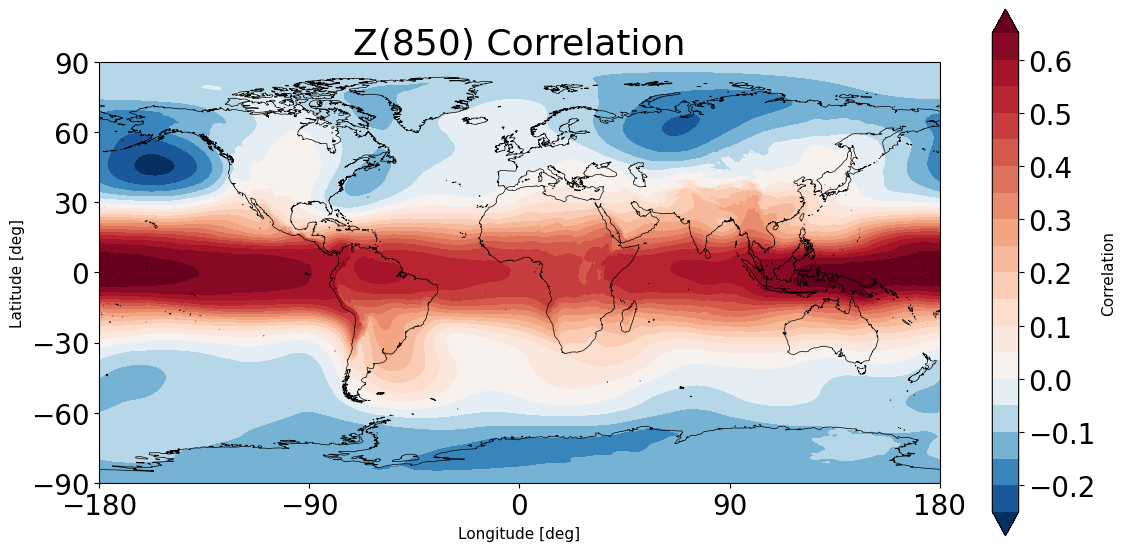

In [5]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
norm = TwoSlopeNorm(vmin=-0.4, vcenter=0, vmax=0.8)

cf = ax.contourf(
    z850corr2df.longitude, 
    z850corr2df.latitude, 
    z850corr2df.Z,
    levels=21,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    extend='both',
    norm = TwoSlopeNorm(vmin=z850corr2df.Z.min(), vcenter=0, vmax=z850corr2df.Z.max())
)

cbar = plt.colorbar(cf, ax=ax, orientation='vertical')
cbar.set_label('Correlation', fontsize=11)

ax.set_title("Z(850) Correlation")
ax.set_xticks(range(-180, 181, 90), crs=ccrs.PlateCarree())
ax.set_yticks(range(-90, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude [deg]', fontsize=11)
ax.set_ylabel('Latitude [deg]', fontsize=11)
ax.coastlines(resolution='50m', linewidth=0.5)
plt.tight_layout()
plt.savefig('z8502dcorr.png', dpi=300)
plt.show()

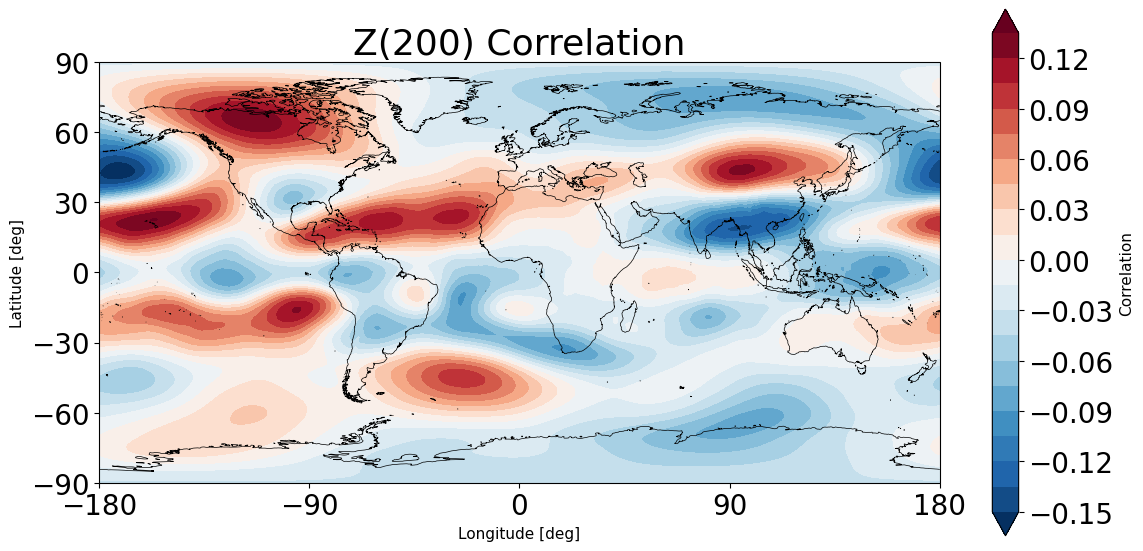

In [28]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

cf = ax.contourf(
    z200corr2df.longitude, 
    z200corr2df.latitude, 
    z200corr2df.Z,
    levels=21,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    extend='both',
    norm = TwoSlopeNorm(vmin=z200corr2df.Z.min(), vcenter=0, vmax=z200corr2df.Z.max())
)

cbar = plt.colorbar(cf, ax=ax, orientation='vertical')
cbar.set_label('Correlation', fontsize=11)

ax.set_title("Z(200) Correlation")
ax.set_xticks(range(-180, 181, 90), crs=ccrs.PlateCarree())
ax.set_yticks(range(-90, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude [deg]', fontsize=11)
ax.set_ylabel('Latitude [deg]', fontsize=11)
ax.coastlines(resolution='50m', linewidth=0.5)
plt.tight_layout()
plt.savefig('z2002dcorr.png', dpi=300)
plt.show()

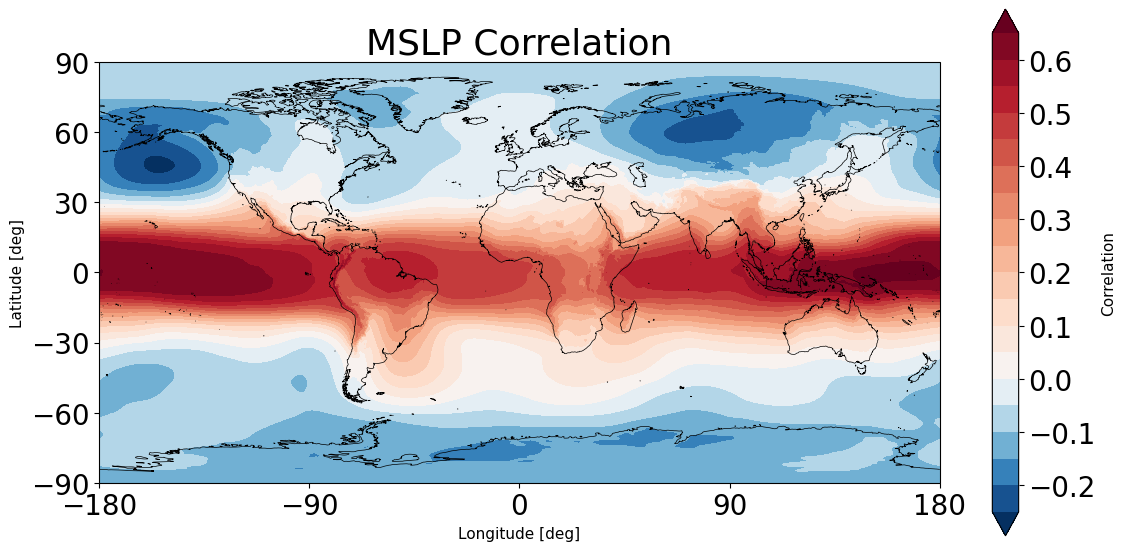

In [5]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
norm = TwoSlopeNorm(vmin=-0.4, vcenter=0, vmax=0.8)

cf = ax.contourf(
    MSLcorr2df.longitude, 
    MSLcorr2df.latitude, 
    MSLcorr2df.MSL,
    levels=21,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    extend='both',
    norm = TwoSlopeNorm(vmin=MSLcorr2df.MSL.min(), vcenter=0, vmax=MSLcorr2df.MSL.max())
)

cbar = plt.colorbar(cf, ax=ax, orientation='vertical')
cbar.set_label('Correlation', fontsize=11)

ax.set_title("MSLP Correlation")
ax.set_xticks(range(-180, 181, 90), crs=ccrs.PlateCarree())
ax.set_yticks(range(-90, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude [deg]', fontsize=11)
ax.set_ylabel('Latitude [deg]', fontsize=11)
ax.coastlines(resolution='50m', linewidth=0.5)
plt.tight_layout()
plt.savefig('MSL2dcorr.png', dpi=300)
plt.show()

In [ ]:
precipcorr2dlagn7, _ = uf.lag_corr_2d(z850index, highpprecipshaved.MTPR, -7, f'{WORK}/tam/temp/')

In [ ]:
precipcorr2dlagn7 = precipcorr2dlagn7.rename({'__xarray_dataarray_variable__':'MTPR'})

In [ ]:
precipcorr2dlagn7.to_netcdf(f'{WORK}/tam/corr2d/precipcorr2dlagn7.nc')

In [ ]:
precipcorr2dflagn7 = xr.open_mfdataset(f'{WORK}/tam/corr2d/precipcorr2dlagn7.nc').compute()

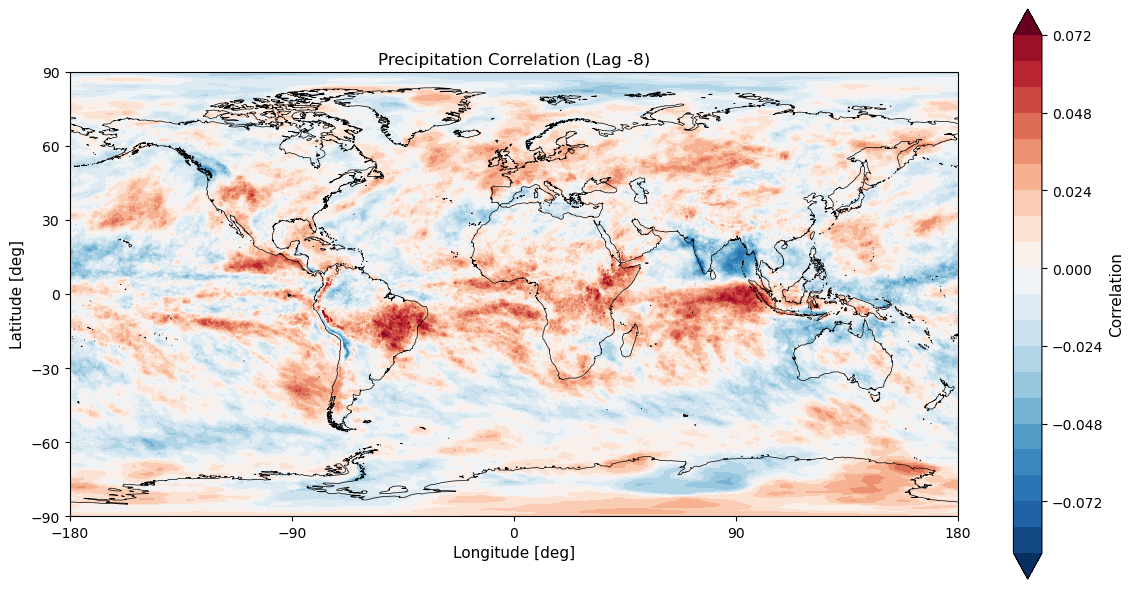

In [12]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

cf = ax.contourf(
    precipcorr2dflagn8.longitude, 
    precipcorr2dflagn8.latitude, 
    precipcorr2dflagn8.MTPR,
    levels=21,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    extend='both',
    norm = TwoSlopeNorm(vmin=precipcorr2dflagn8.MTPR.min(), vcenter=0, vmax=precipcorr2dflagn8.MTPR.max())
)

cbar = plt.colorbar(cf, ax=ax, orientation='vertical')
cbar.set_label('Correlation', fontsize=11)

ax.set_title("Precipitation Correlation (Lag -8)")
ax.set_xticks(range(-180, 181, 90), crs=ccrs.PlateCarree())
ax.set_yticks(range(-90, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude [deg]', fontsize=11)
ax.set_ylabel('Latitude [deg]', fontsize=11)
ax.coastlines(resolution='50m', linewidth=0.5)
plt.tight_layout()
plt.savefig('precip2dcorrnlag7.png', dpi=300)
plt.show()

In [ ]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
norm = TwoSlopeNorm(vmin=-0.4, vcenter=0, vmax=0.8)

cf = ax.contourf(
    z850corr2d.longitude, 
    z850corr2d.latitude, 
    z850corr2d,
    levels=np.linspace(-0.4, 0.8, 13),
    cmap='RdBu_r',
    norm=norm,  
    transform=ccrs.PlateCarree(),
    extend='both'
)

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
cbar.set_label('Correlation', fontsize=11)

ax.set_title("Z(850) Correlation")
ax.set_ylabel("Latitude (deg)")
ax.set_xlabel("Longitude (deg)")
ax.coastlines()
plt.show()

In [ ]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
norm = TwoSlopeNorm(vmin=-0.4, vcenter=0, vmax=0.8)

cf = ax.pcolormesh(
    z850corr2d.longitude, 
    z850corr2d.latitude, 
    z850corr2d,
    cmap='RdBu_r',
    norm=norm, 
    transform=ccrs.PlateCarree(),
    shading='nearest'
)
cf.set_rasterized(True)
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.05, aspect=50)
cbar.set_label('Correlation', fontsize=11)

ax.set_title("Z(850) Correlation")
ax.set_ylabel("Latitude (deg)")
ax.set_xlabel("Longitude (deg)")
#ax.set_xticks(np.arange(-180, 181, 90))
#ax.set_yticks(np.arange(-90, 91, 30))
ax.coastlines()
#plt.savefig('z8502dcorr.png', dpi=300)
